In [13]:
import geopandas as gpd
import matplotlib.pyplot as plt

pipes = gpd.read_file("Multiple_Pipes_Sewage.geojson")

pipes.head()

,OBJECTID_1,FEAT_NUM,MATERIAL,SHAPE_LN,WIDTH,HEIGHT,NEW_CMPU_LEN,US_IL,DS_IL,CELL_NUM,COORX,COORY,FR_PNT,TO_PNT,SHAPE_LENGTH,OBJECTID_2,geometry
0,1,FMD1000020,Vitrified Clay,Circular,600.0,None,9.434055,NaN,NaN,2,836300.9998,834991.9999,FTH1000036,FMH1000130,9.434055,1,"LINESTRING (114.1772 22.45439, 114.17724 22.45..."
1,2,FMD1000021,Vitrified Clay,Circular,600.0,None,10.770330,NaN,NaN,2,836302.0001,834974.0000,FTH1000037,FMH1000130,10.770330,2,"LINESTRING (114.1772 22.45423, 114.17724 22.45..."
2,3,FMD1000040,Vitrified Clay,Circular,375.0,None,8.246866,2.79,NaN,2,835409.9999,834256.9996,FMH1000592,FMH1000593,8.246866,3,"LINESTRING (114.16854 22.44775, 114.16862 22.4..."
3,4,FMD1000061,Vitrified Clay,Circular,300.0,None,38.000000,NaN,4.5,2,837559.9997,835535.0000,FMH1005259,FMH1005258,38.000000,4,"LINESTRING (114.18943 22.45929, 114.18906 22.4..."
4,9,FMD1000100,Cast Iron,Circular,150.0,None,10.049159,4.85,4.6,3,836251.0006,835294.9998,FMH1000573,FMH1000422,10.049159,5,"LINESTRING (114.17671 22.45712, 114.17681 22.4..."


In [14]:
!pip install geopandas

Defaulting to user installation because normal site-packages is not writeable


In [15]:
pipes.geometry.head()
pipes.crs
pipes.shape

(2163, 17)

<Axes: >

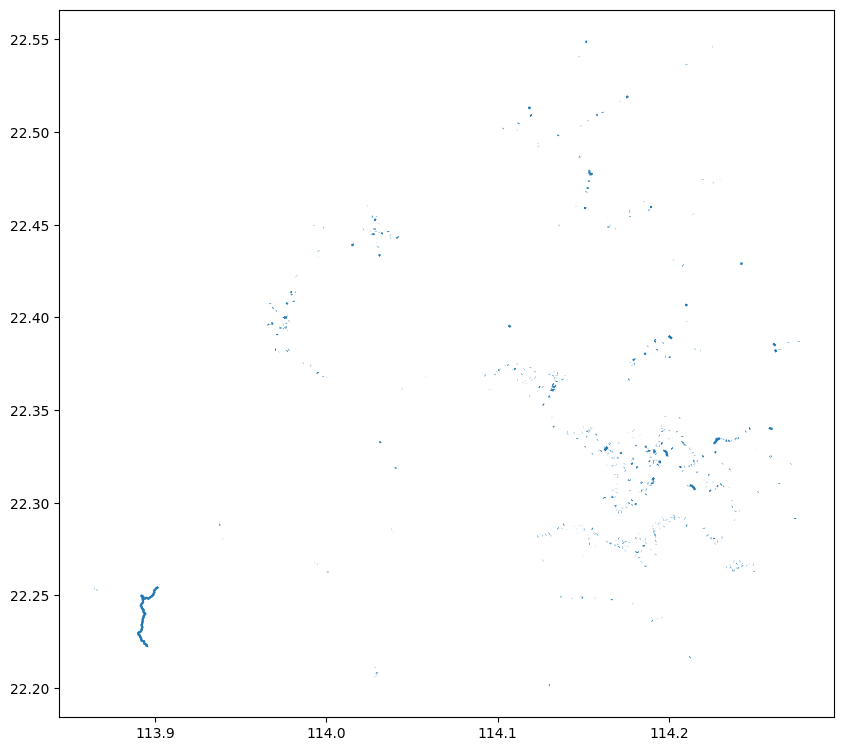

In [16]:
pipes.plot(figsize=(10,10))

In [30]:
from shapely.geometry import Point

print(pipes.crs)

pipes_m = pipes.to_crs(epsg=2326)

tree_lon = 114.1772
tree_lat = 22.4544

tree = gpd.GeoDataFrame(
    {'tree_id': [1]},
    geometry=[Point(tree_lon, tree_lat)],
    crs='EPSG:4326'
).to_crs(epsg=2326)

root_radius_m = 5
root_buffer = tree.buffer(root_radius_m).iloc[0]

# result is (2,17): means that root area and 2 pipes conflict
conflicting_pipes = pipes_m[pipes_m.geometry.intersects(root_buffer)]

conflicting_pipes.shape

EPSG:4326


(2, 17)

In [18]:
if len(conflicting_pipes) > 0:
    alert = "High"
else:
    alert = "Low"

alert

'High'

<Axes: >

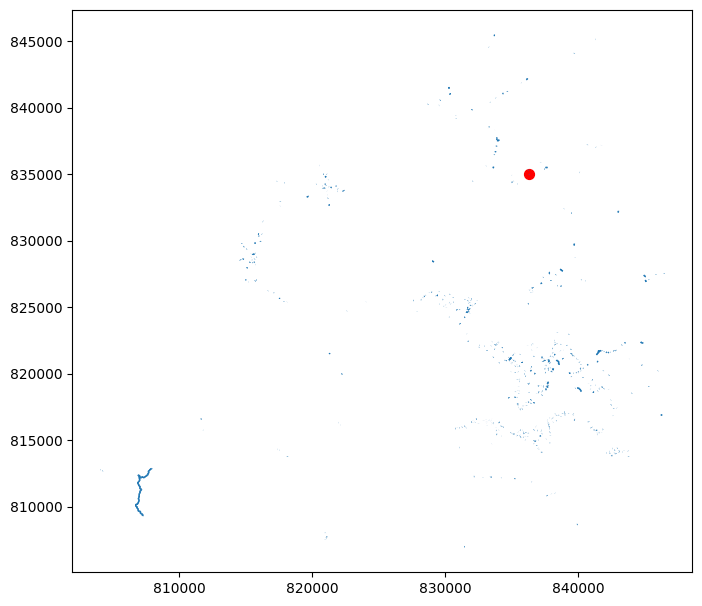

In [19]:
ax = pipes_m.plot(figsize=(8,8), linewidth=1)

gpd.GeoSeries([root_buffer], crs=pipes_m.crs).plot(
    ax=ax,
    alpha=0.3,
    edgecolor='red'
)

tree.plot(ax=ax, color='red', markersize=50)

In [20]:
root_buffer = tree.buffer(root_radius_m).iloc[0]

In [29]:
# Take the first pipe
sample_pipe = pipes_m.iloc[0]

# Get the midpoint of that pipe
tree_point = sample_pipe.geometry.interpolate(0.5, normalized=True)

# Create tree GeoDataFrame
tree = gpd.GeoDataFrame(
    {'tree_id':[1]},
    geometry=[tree_point],
    crs=pipes_m.crs
)

# Create root zone (5 m radius)
root_radius_m = 5
root_buffer = tree.buffer(root_radius_m).iloc[0]

# Find intersecting pipes
conflicting_pipes = pipes_m[
    pipes_m.geometry.intersects(root_buffer)
]

print(conflicting_pipes.shape)

if len(conflicting_pipes) > 0:
    print("HIGH ALERT")
else:
    print("LOW ALERT")

(4, 17)
HIGH ALERT


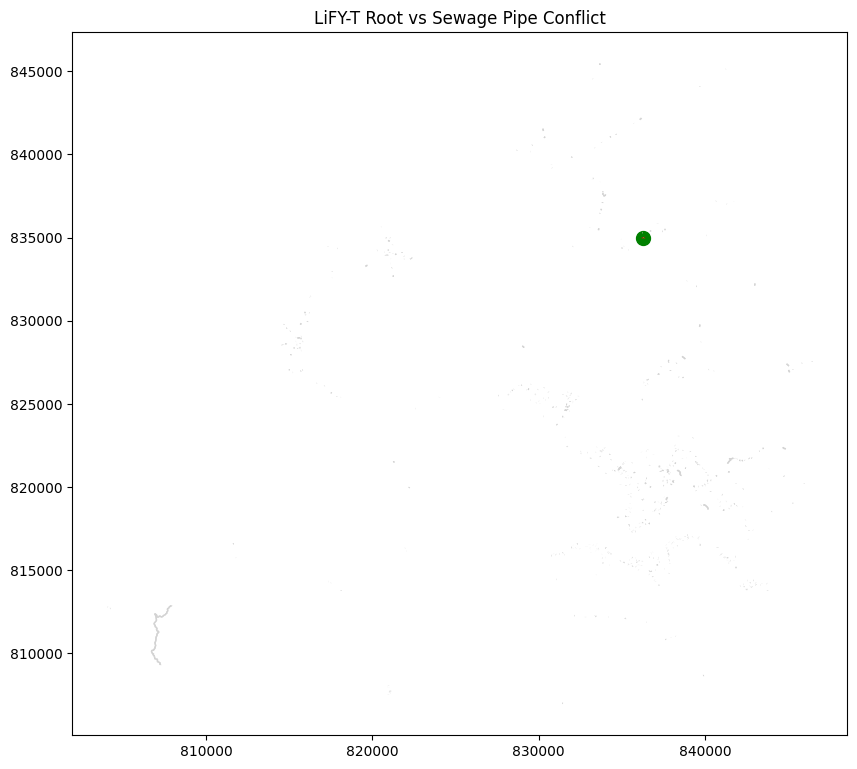

In [22]:
ax = pipes_m.plot(
    figsize=(10,10),
    color='lightgray',
    linewidth=1
)

# All conflicting pipes
conflicting_pipes.plot(
    ax=ax,
    color='red',
    linewidth=3
)

# Root zone
gpd.GeoSeries(
    [root_buffer],
    crs=pipes_m.crs
).plot(
    ax=ax,
    color='orange',
    alpha=0.3,
    edgecolor='orange'
)

# Tree
tree.plot(
    ax=ax,
    color='green',
    markersize=100
)

plt.title("LiFY-T Root vs Sewage Pipe Conflict")
plt.show()

In [23]:
print(root_radius_m)
print(root_buffer.area)

5
78.41371226380164


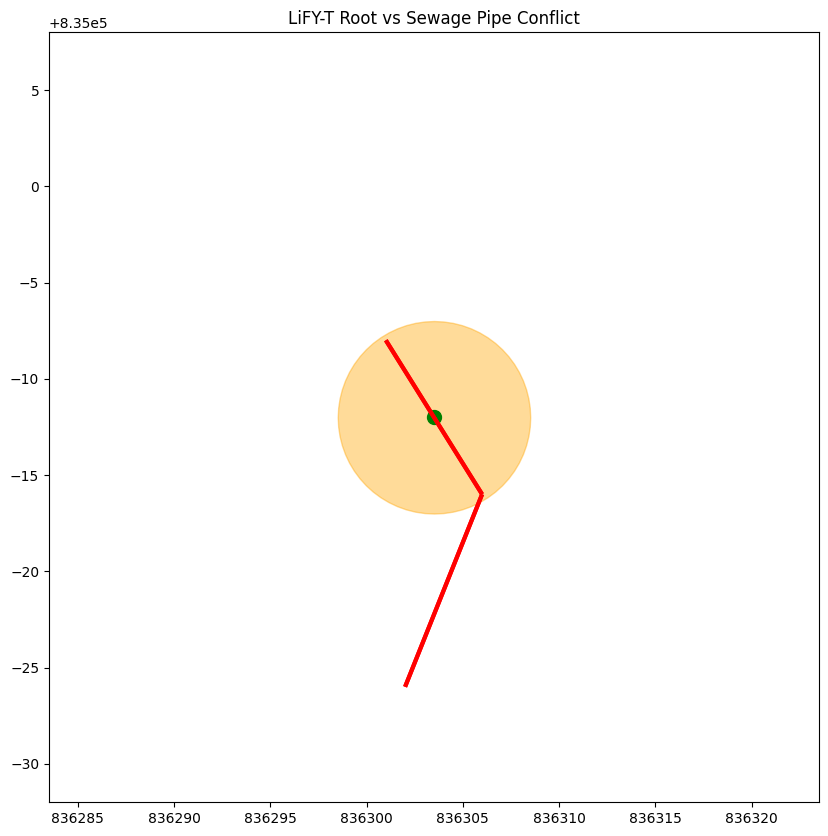

In [24]:
ax = pipes_m.plot(
    figsize=(10,10),
    color='lightgray',
    linewidth=1
)

conflicting_pipes.plot(
    ax=ax,
    color='red',
    linewidth=3
)

gpd.GeoSeries(
    [root_buffer],
    crs=pipes_m.crs
).plot(
    ax=ax,
    color='orange',
    alpha=0.4,
    edgecolor='orange'
)

tree.plot(
    ax=ax,
    color='green',
    markersize=100
)

# ZOOM TO TREE
x, y = tree.geometry.iloc[0].x, tree.geometry.iloc[0].y

ax.set_xlim(x-20, x+20)
ax.set_ylim(y-20, y+20)

plt.title("LiFY-T Root vs Sewage Pipe Conflict")
plt.show()

In [25]:
print(conflicting_pipes.shape)

(4, 17)


In [28]:
if len(conflicting_pipes) > 0:
    print("HIGH ALERT")
else:
    print("LOW ALERT")

HIGH ALERT


In [31]:
single_pipes = gpd.read_file("single_pipe_hk.geojson")

single_pipes.head()
single_pipes.shape
single_pipes.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [32]:
print(single_pipes.shape)

(125121, 17)


In [33]:
print(single_pipes.columns)
print(pipes.columns)

Index(['OBJECTID_1', 'FEAT_NUM', 'MATERIAL', 'SHAPE_LN', 'WIDTH', 'HEIGHT',
       'NEW_CMPU_LEN', 'US_IL', 'DS_IL', 'CELL_NUM', 'COORX', 'COORY',
       'FR_PNT', 'TO_PNT', 'SHAPE_LENGTH', 'OBJECTID_2', 'geometry'],
      dtype='object')
Index(['OBJECTID_1', 'FEAT_NUM', 'MATERIAL', 'SHAPE_LN', 'WIDTH', 'HEIGHT',
       'NEW_CMPU_LEN', 'US_IL', 'DS_IL', 'CELL_NUM', 'COORX', 'COORY',
       'FR_PNT', 'TO_PNT', 'SHAPE_LENGTH', 'OBJECTID_2', 'geometry'],
      dtype='object')


<Axes: >

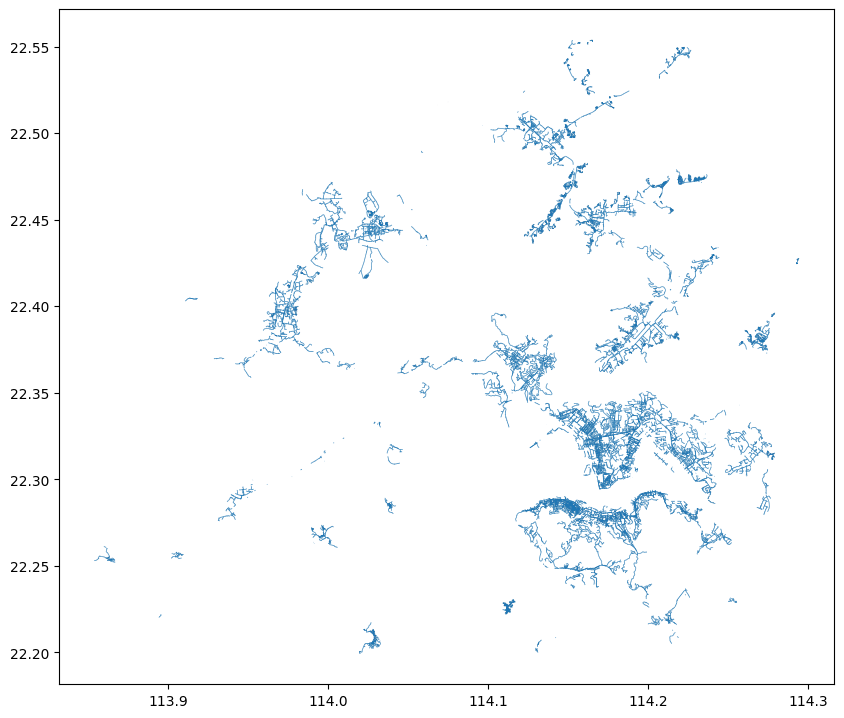

In [34]:
single_pipes.plot(
    figsize=(10,10),
    linewidth=0.5
)

In [35]:
import pandas as pd

all_sewage = gpd.GeoDataFrame(
    pd.concat([single_pipes, pipes], ignore_index=True),
    crs=single_pipes.crs
)

all_sewage.shape

/var/folders/r0/d2q3kdcd6dvgp_y46tk_5mdm0000gn/T/ipykernel_58314/4119935078.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd.concat([single_pipes, pipes], ignore_index=True),


(127284, 17)

In [36]:
single_pipes['source_layer'] = 'Pipe (Sewage)'
pipes['source_layer'] = 'Multiple Pipes (Sewage)'

all_sewage = gpd.GeoDataFrame(
    pd.concat([single_pipes, pipes], ignore_index=True),
    crs=single_pipes.crs
)

all_sewage.shape

/var/folders/r0/d2q3kdcd6dvgp_y46tk_5mdm0000gn/T/ipykernel_58314/3657853793.py:5: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd.concat([single_pipes, pipes], ignore_index=True),


(127284, 18)

In [37]:
all_sewage_m = all_sewage.to_crs(epsg=2326)

conflicting_pipes = all_sewage_m[
    all_sewage_m.geometry.intersects(root_buffer)
]

conflicting_pipes[['source_layer','MATERIAL','SHAPE_LN','WIDTH','NEW_CMPU_LEN']].head()

,source_layer,MATERIAL,SHAPE_LN,WIDTH,NEW_CMPU_LEN
125121,Multiple Pipes (Sewage),Vitrified Clay,Circular,600.0,9.434055
125408,Multiple Pipes (Sewage),Vitrified Clay,Circular,600.0,9.434055


In [38]:
conflicting_pipes['source_layer'].value_counts()

source_layer
Multiple Pipes (Sewage)    2
Name: count, dtype: int64

In [39]:
conflicting_pipes[
    ['source_layer','FEAT_NUM','NEW_CMPU_LEN']
]

,source_layer,FEAT_NUM,NEW_CMPU_LEN
125121,Multiple Pipes (Sewage),FMD1000020,9.434055
125408,Multiple Pipes (Sewage),FMD1002873,9.434055


In [40]:
nearest_distance = all_sewage_m.distance(tree.geometry.iloc[0]).min()
nearest_distance

np.float64(1.394042905517487)

In [42]:
import requests
import geopandas as gpd
from shapely.geometry import shape

url = "https://portal.csdi.gov.hk/server/rest/services/common/dsd_rcd_1629267205231_36707/FeatureServer/0/query"

params = {
    "where": "1=1",
    "outFields": "*",
    "returnGeometry": "true",
    "f": "geojson"
}

r = requests.get(url, params=params)
print(r.status_code)
print(r.text[:500])

/Users/hwayoungshin/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


200
{"type":"FeatureCollection","features":[{"type":"Feature","id":1,"geometry":{"type":"LineString","coordinates":[[114.17719500183479,22.454388299805821],[114.1772435812351,22.454316057039623]]},"properties":{"OBJECTID_1":1,"OBJECTID":150057,"FEAT_NUM":"FMD1000020","MATERIAL":"Vitrified Clay","SHAPE_LN":"Circular","WIDTH":600,"HEIGHT":null,"NEW_CMPU_LEN":9.4340553400000005,"US_IL":null,"DS_IL":null,"CELL_NUM":2,"COORX":836300.99980000104,"COORY":834991.99990000203,"FR_PNT":"FTH1000036","TO_PNT":"F


In [43]:
data = r.json()

pipes_api = gpd.GeoDataFrame.from_features(
    data["features"],
    crs="EPSG:4326"
)

pipes_api.head()

,geometry,OBJECTID_1,OBJECTID,FEAT_NUM,MATERIAL,SHAPE_LN,WIDTH,HEIGHT,NEW_CMPU_LEN,US_IL,DS_IL,CELL_NUM,COORX,COORY,FR_PNT,TO_PNT,OBJECTID_2,Shape__Length
0,"LINESTRING (114.1772 22.45439, 114.17724 22.45...",1,150057,FMD1000020,Vitrified Clay,Circular,600.0,None,9.434055,NaN,NaN,2,836300.9998,834991.9999,FTH1000036,FMH1000130,1,9.434055
1,"LINESTRING (114.1772 22.45423, 114.17724 22.45...",2,149999,FMD1000021,Vitrified Clay,Circular,600.0,None,10.770330,NaN,NaN,2,836302.0001,834974.0000,FTH1000037,FMH1000130,2,10.770330
2,"LINESTRING (114.16854 22.44775, 114.16862 22.4...",3,149904,FMD1000040,Vitrified Clay,Circular,375.0,None,8.246866,2.79,NaN,2,835409.9999,834256.9996,FMH1000592,FMH1000593,3,8.246866
3,"LINESTRING (114.18943 22.45929, 114.18906 22.4...",4,150063,FMD1000061,Vitrified Clay,Circular,300.0,None,38.000000,NaN,4.5,2,837559.9997,835535.0000,FMH1005259,FMH1005258,4,38.000000
4,"LINESTRING (114.17671 22.45712, 114.17681 22.4...",9,150065,FMD1000100,Cast Iron,Circular,150.0,None,10.049159,4.85,4.6,3,836251.0006,835294.9998,FMH1000573,FMH1000422,5,10.049159


In [44]:
pipes_api.shape

(2163, 18)

In [45]:
print(pipes.shape)
print(pipes_api.shape)

(2163, 18)
(2163, 18)


In [46]:
pipes_api["FEAT_NUM"].head()
pipes["FEAT_NUM"].head()

0    FMD1000020
1    FMD1000021
2    FMD1000040
3    FMD1000061
4    FMD1000100
Name: FEAT_NUM, dtype: object

In [48]:
tree_x = 836304
tree_y = 834999

params = {
    "geometry": f"{tree_x},{tree_y}",
    "geometryType": "esriGeometryPoint",
    "distance": 50,
    "units": "esriSRUnit_Meter",
    "outFields": "*",
    "returnGeometry": "true",
    "f": "geojson"
}

In [49]:
r_local = requests.get(url, params=params)

print(r_local.status_code)

data_local = r_local.json()

print(len(data_local["features"]))

200
4


In [50]:
pipes_local = gpd.GeoDataFrame.from_features(
    data_local["features"],
    crs="EPSG:4326"
)

pipes_local[
    ["FEAT_NUM","MATERIAL","NEW_CMPU_LEN"]
]

,FEAT_NUM,MATERIAL,NEW_CMPU_LEN
0,FMD1000020,Vitrified Clay,9.434055
1,FMD1000021,Vitrified Clay,10.770330
2,FMD1002852,Vitrified Clay,10.770330
3,FMD1002873,Vitrified Clay,9.434055
